In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./NOMBRE_DE_ESTE_NOTEBOOK.ipynb")  # <-- ajusta

seed = 0
run_logger = NBRunLogger("ho", "DV", seed=seed, tag="test")  # <-- cambia box/DV según notebook

# Guardado automático de figuras aunque NO haya plt.show()
run_logger.enable_autosave_figures_each_cell()

print("RUN_DIR:", run_logger.run_dir.resolve())
print("FIG_DIR:", run_logger.fig_dir.resolve())
print("ART_DIR:", run_logger.art_dir.resolve())


RUN_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\ho\DV\20260205-153615_seed0_test
FIG_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\ho\DV\20260205-153615_seed0_test\figures
ART_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\ho\DV\20260205-153615_seed0_test\artifacts


In [3]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float32"   # DVPDESolver/DVQuantumLayer trabajan más estable así en tu repo

torch.manual_seed(0)
if device == "cuda":
    torch.cuda.manual_seed_all(0)

print("device:", device, "| dtype:", dtype)


device: cpu | dtype: float32


In [4]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)

from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging


In [5]:
eq_params = build_eq_params(
    "ho",
    L=6.0,          # dominio truncado [-L, L]
    T=0.2,
    mass=1.0,
    hbar=1.0,
    omega=1.0,
    n_level=0,      # prueba n=1 primero
    num_grid=800,
)

print("eq_params:", eq_params)
print("sanity:", sanity_check(eq_params, device=device))


eq_params: {'example': 'ho', 'L': 6.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 0, 'x_min': -6.0, 'x_max': 6.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 1.2, 'x_center': 3.0, 'num_grid': 800}
sanity: {'V_min': 0.00045453397641474763, 'V_max': 18.0, 'psi0_norm': 0.28795254238618323, 'psiT_norm': 0.28795254238618323}


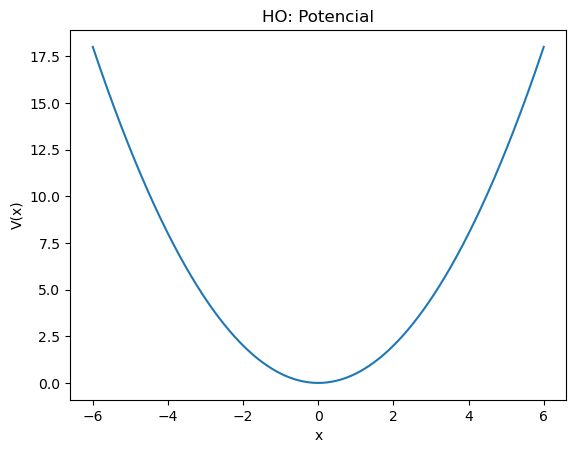

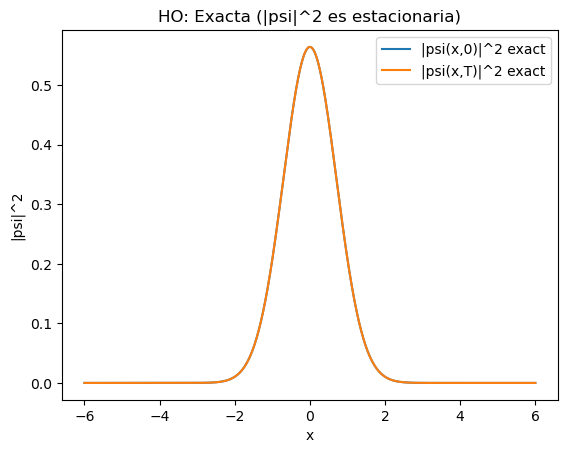

In [6]:
pb = build_problem(
    eq_params,
    device=torch.device(device),
    dtype=torch.float32 if "32" in dtype else torch.float64
)

x = torch.linspace(pb["x_min"], pb["x_max"], 1200, device=device, dtype=pb["dtype"]).reshape(-1, 1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    V = pb["potential_fn"](t0, x)
    r0,i0,_ = pb["exact"](pb["n_level"], t0, x)
    rT,iT,_ = pb["exact"](pb["n_level"], tT, x)

x_cpu = x.detach().cpu().numpy().flatten()
V_cpu = V.detach().cpu().numpy().flatten()
p0_cpu = (r0**2 + i0**2).detach().cpu().numpy().flatten()
pT_cpu = (rT**2 + iT**2).detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, V_cpu)
plt.xlabel("x"); plt.ylabel("V(x)")
plt.title("HO: Potencial")
plt.show()

plt.figure()
plt.plot(x_cpu, p0_cpu, label="|psi(x,0)|^2 exact")
plt.plot(x_cpu, pT_cpu, label="|psi(x,T)|^2 exact")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi|^2")
plt.title("HO: Exacta (|psi|^2 es estacionaria)")
plt.show()


In [7]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",
    "dv_batching": True,
    "pde_chunk_size": 128,
    "dv_batching_mode": "broadcast",
    


    # training
    "epochs": 10,        # smoke test (sube luego a 1500-3000)
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 1,

    # pesos (HO suele ir bien con esto)
    "w_pde": 1.0,
    "w_bc":  1.0,         # cola ~0 en bordes del dominio truncado
    "w_ic":  200.0,
    "w_norm": 5.0,
    "w_pde_i": 10.0,
    "w_ic_i": 5.0,
    

    "warmup_epochs": 20,
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV (circuito)
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,        # requerido por el layer aunque default.qubit no lo use
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19",

    # red híbrida (ojo: en DVPDESolver solo usa [-2] y [-1])
    "classic_network": [2, 64, 2],   # input=2 (t,x), hidden=64, output=2 (Re,Im)
}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "ho_DV")
model = DVPDESolver(args, logger, device=torch.device(device))
model.args = args

# opcional: no dibujar el circuito cada corrida (ahorra tiempo)
model.draw_quantum_circuit_flag = False

print("DV model built.")


DV model built.


In [8]:
run_logger.log_config(eq_params=eq_params, args=args)


In [9]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)


Trainable params: {'total': 918, 'quantum': 16, 'classical': 902}


In [10]:
param_dtype = next(model.parameters()).dtype
t_test = torch.rand(8, 1, device=device, dtype=param_dtype) * eq_params["T"]
x_test = (torch.rand(8, 1, device=device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"])
y = model(torch.cat([t_test, x_test], dim=1))

print("forward ok ->", y.shape, y.dtype, y.device)


forward ok -> torch.Size([8, 2]) torch.float32 cpu


QNode encontrado en quantum_layer.circuit
0: ─╭AngleEmbedding(M0)──RX(1.52)───RZ(-0.29)─╭||─╭X──────────────╭●──────────RX(0.09)─ ···
1: ─├AngleEmbedding(M0)──RX(-0.25)──RZ(0.08)──├||─│─────╭●────────╰X──────────RX(0.70)─ ···
2: ─├AngleEmbedding(M0)──RX(-0.21)──RZ(-0.19)─├||─│──╭●─╰X─────────RX(-0.17)──RZ(-0.09) ···
3: ─╰AngleEmbedding(M0)──RX(0.78)───RZ(0.21)──╰||─╰●─╰X──RX(0.62)──RZ(0.36)──────────── ···

0: ··· ──RZ(-0.46)─╭||─╭X───────╭●─┤  <Z>
1: ··· ──RZ(-0.73)─├||─│─────╭●─╰X─┤  <Z>
2: ··· ────────────├||─│──╭●─╰X────┤  <Z>
3: ··· ────────────╰||─╰●─╰X───────┤  <Z>

M0 = 
tensor([0., 0., 0., 0.])


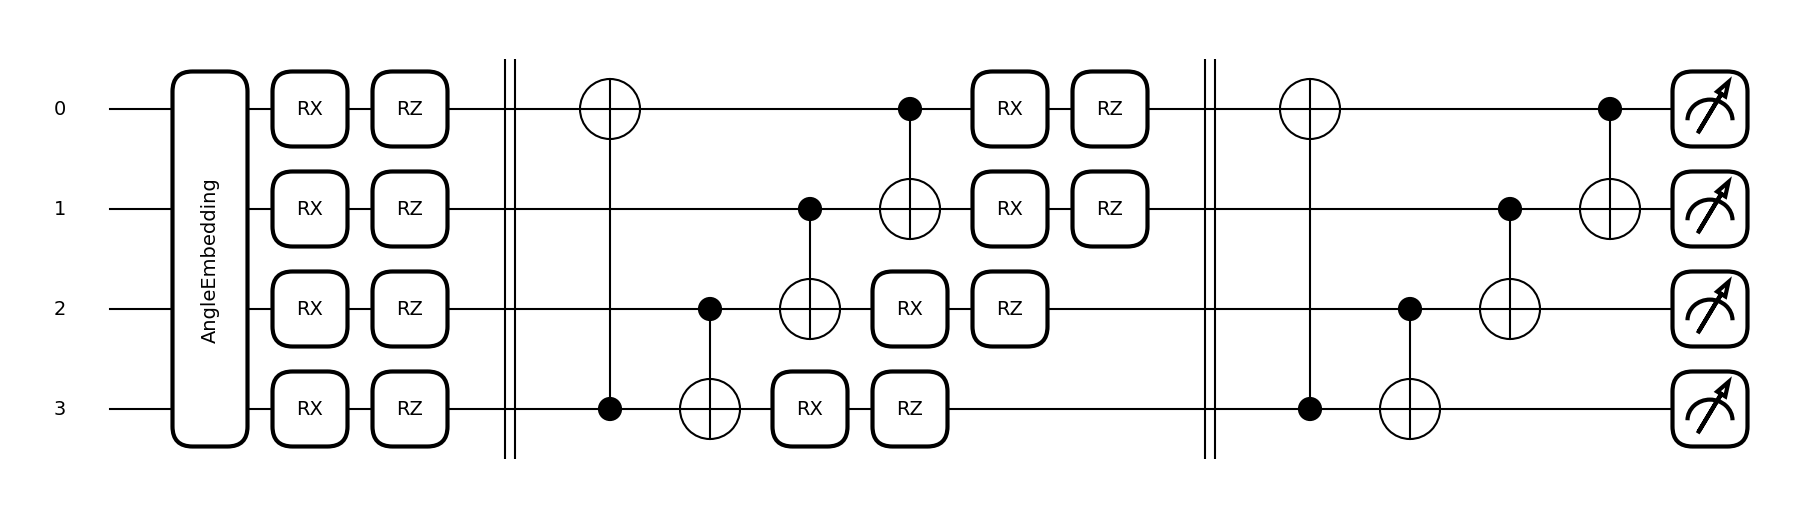

In [11]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt

ql = model.quantum_layer

# Encontrar el QNode (ya viste que está en quantum_layer.circuit)
qnode = getattr(ql, "qnode", None)
if qnode is None:
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            qnode = val
            break
if qnode is None:
    raise RuntimeError("No encontré un QNode dentro de model.quantum_layer")

# Input para dibujar (ajusta longitud según tu circuito)
dev = next(model.parameters()).device
dt  = next(model.parameters()).dtype

# Prueba con 4 (tu num_qubits=4); si falla, baja a 2.
n = model.args.get("num_qubits", 4) if hasattr(model, "args") else 4
x_draw = torch.zeros(n, device=dev, dtype=dt)
if n >= 2:
    x_draw[0] = 0.0  # t
    x_draw[1] = 0.0  # x

# 1) ASCII
try:
    drawer_txt = qml.draw(qnode)     # <- sin expansion_strategy
    print(drawer_txt(x_draw))
except Exception as e:
    print("No pude dibujar en ASCII con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_txt = qml.draw(qnode)
    print(drawer_txt(x2))

# 2) Figura (matplotlib)
try:
    drawer_fig = qml.draw_mpl(qnode) # <- sin expansion_strategy
    fig, ax = drawer_fig(x_draw)
    plt.show()
except Exception as e:
    print("No pude dibujar con draw_mpl con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_fig = qml.draw_mpl(qnode)
    fig, ax = drawer_fig(x2)
    plt.show()


In [12]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)

    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, encoding="utf-8"),
        ],
        force=True,
    )

    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

force_live_logging(run_logger.art_dir / "python.log")


In [13]:
import logging
lg = logging.getLogger("src.utils.logger")
lg.handlers.clear()
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


In [14]:
train(model, N_f=500, N_b=128, N_0=260)


INFO:src.utils.logger:It: 1, Loss: 2.216e+01, Loss_res: 4.523e+00,  Loss_bcs: 7.851e-03, Loss_ut_ics: 9.492e-02, Loss_norm: 5.890e-01, Loss_gauge: 0.000e+00, w_pde: 5.00e-02, L^2_error: 7.859e-01, lr: 1.000e-03, Time: 2.34e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_15-36-30-080787_ho_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_15-36-30-080787_ho_DV\model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 1.758e+01, Loss_res: 2.045e+00,  Loss_bcs: 4.394e-03, Loss_ut_ics: 7.051e-02, Loss_norm: 6.546e-01, Loss_gauge: 0.000e+00, w_pde: 1.00e-01, L^2_error: 7.564e-01, lr: 1.000e-03, Time: 4.68e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_15-36-30-080787_ho_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_15-36-30-080787_ho_DV\model_weight

In [15]:
meta = run_logger.log_histories(model)
print("history_meta:", meta)

parsed = run_logger.parse_schrodinger_train_log()
print("Puntos parseados del log:", len(parsed["it"]))
print("Último it/loss/l2:", parsed["it"][-1], parsed["loss"][-1], parsed["l2"][-1])


history_meta: {'loss_history_len': 10, 'l2_rel_history_len': 10, 'loss_history_type': "<class 'list'>", 'l2_rel_history_type': "<class 'list'>"}
Puntos parseados del log: 10
Último it/loss/l2: 10 10.1 0.65


L2_rel(T): 0.6499410271644592


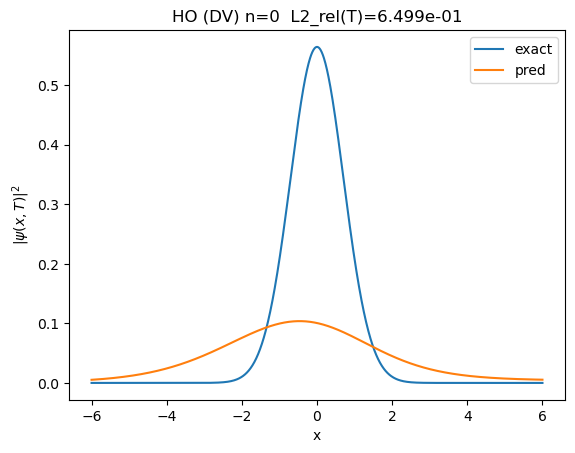

In [16]:
import torch
import matplotlib.pyplot as plt
from src.problems.schrodinger.problem import build_problem

def normalize_dtype(dt):
    if isinstance(dt, torch.dtype):
        return dt
    if isinstance(dt, str):
        dt = dt.lower()
        if "32" in dt:
            return torch.float32
        if "64" in dt:
            return torch.float64
    raise ValueError(f"dtype no reconocido: {dt} ({type(dt)})")

pb = build_problem(
    eq_params,
    device=torch.device(device),
    dtype=normalize_dtype(dtype)
)

x = torch.linspace(pb["x_min"], pb["x_max"], 1200, device=pb["device"], dtype=pb["dtype"]).reshape(-1, 1)
t = torch.full_like(x, float(pb["T"]))

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:, 0:1], pred[:, 1:2]
    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    l2_rel = (l2_abs / ref).item()

print("L2_rel(T):", l2_rel)

prob_pred  = (pr**2 + pi**2).detach().cpu().numpy().flatten()
prob_exact = (er**2 + ei**2).detach().cpu().numpy().flatten()
x_cpu      = x.detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  label="pred")
plt.legend()
plt.xlabel("x"); plt.ylabel(r"$|\psi(x,T)|^2$")
plt.title(f"HO (DV) n={eq_params['n_level']}  L2_rel(T)={l2_rel:.3e}")
plt.show()



In [17]:
x = torch.linspace(pb["x_min"], pb["x_max"], 1400, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    p0 = model(torch.cat([t0, x], dim=1))
    pT = model(torch.cat([tT, x], dim=1))

    prob0 = p0[:,0]**2 + p0[:,1]**2
    probT = pT[:,0]**2 + pT[:,1]**2

    norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
    normT = torch.trapz(probT, x.squeeze(-1)).item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)


Norm pred t=0: 0.492776095867157
Norm pred t=T: 0.5275751352310181


In [18]:
print("broadcast_ok:", getattr(model.quantum_layer, "_broadcast_ok", None))
print("dv_batching_mode:", getattr(model.quantum_layer, "dv_batching_mode", None))


broadcast_ok: True
dv_batching_mode: broadcast


In [19]:
import torch

def count_params(model):
    total = 0
    trainable = 0
    by_block = {}  # desglose por prefijo: preprocessor / quantum_layer / postprocessor / hidden / etc.

    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n

        block = name.split(".")[0]  # primer prefijo (preprocessor, quantum_layer, postprocessor, etc.)
        by_block.setdefault(block, {"total": 0, "trainable": 0})
        by_block[block]["total"] += n
        if p.requires_grad:
            by_block[block]["trainable"] += n

    return total, trainable, by_block


total, trainable, by_block = count_params(model)

print(f"Total parámetros (incluye no-entrenables): {total:,}")
print(f"Parámetros ENTRENABLES (clásicos + cuánticos): {trainable:,}\n")

print("Desglose por bloque (trainables / total):")
for k, v in sorted(by_block.items(), key=lambda kv: -kv[1]["trainable"]):
    print(f"  - {k:15s}: {v['trainable']:,} / {v['total']:,}")

# si quieres además listar SOLO los tensores entrenables:
print("\nListado de parámetros entrenables:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:40s} {tuple(p.shape)}  numel={p.numel():,}  dtype={p.dtype}")



Total parámetros (incluye no-entrenables): 918
Parámetros ENTRENABLES (clásicos + cuánticos): 918

Desglose por bloque (trainables / total):
  - preprocessor   : 452 / 452
  - postprocessor  : 450 / 450
  - quantum_layer  : 16 / 16

Listado de parámetros entrenables:
  preprocessor.0.weight                    (64, 2)  numel=128  dtype=torch.float32
  preprocessor.0.bias                      (64,)  numel=64  dtype=torch.float32
  preprocessor.2.weight                    (4, 64)  numel=256  dtype=torch.float32
  preprocessor.2.bias                      (4,)  numel=4  dtype=torch.float32
  quantum_layer.params                     (2, 8)  numel=16  dtype=torch.float32
  postprocessor.0.weight                   (64, 4)  numel=256  dtype=torch.float32
  postprocessor.0.bias                     (64,)  numel=64  dtype=torch.float32
  postprocessor.2.weight                   (2, 64)  numel=128  dtype=torch.float32
  postprocessor.2.bias                     (2,)  numel=2  dtype=torch.float32


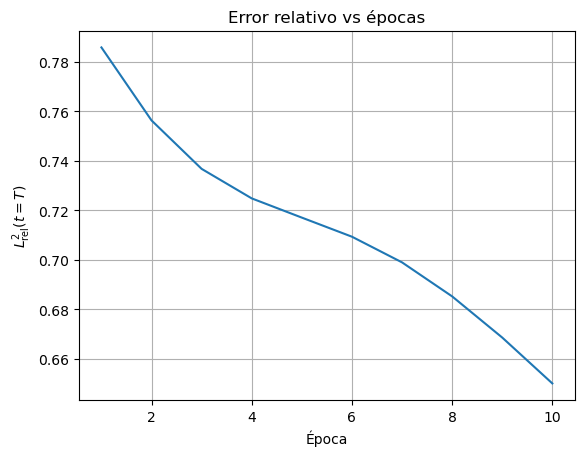

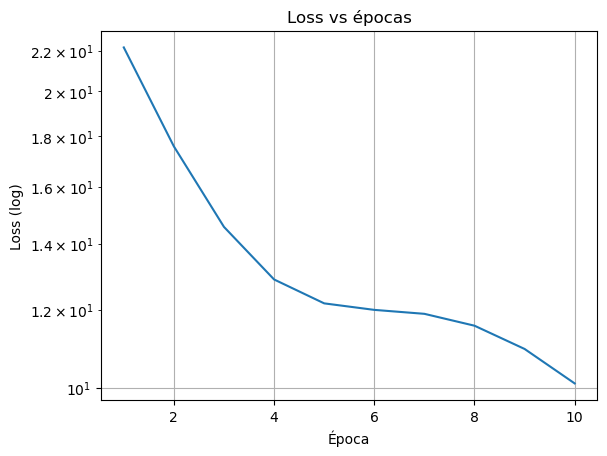

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_history(model):
    # intentos comunes (por si el nombre cambia)
    l2_keys = ["l2_rel_history", "l2_history", "l2_error_history"]
    loss_keys = ["loss_history", "losses", "train_loss_history"]

    l2 = None
    for k in l2_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            l2 = np.array(getattr(model, k), dtype=float)
            break

    loss = None
    for k in loss_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            loss = np.array(getattr(model, k), dtype=float)
            break

    return loss, l2


loss, l2 = get_history(model)

if loss is None:
    raise AttributeError("No encontré historial de pérdida en el modelo (esperaba model.loss_history).")

if l2 is None:
    raise AttributeError("No encontré historial de error L2 en el modelo (esperaba model.l2_rel_history).")

epochs_loss = np.arange(1, len(loss) + 1)
epochs_l2   = np.arange(1, len(l2) + 1)

plt.figure()
plt.plot(epochs_l2, l2)
plt.xlabel("Época")
plt.ylabel(r"$L^2_{\mathrm{rel}}$")
plt.title("Error relativo vs épocas")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_loss, loss)
plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Loss (log)")
plt.title("Loss vs épocas")
plt.grid(True)
plt.show()



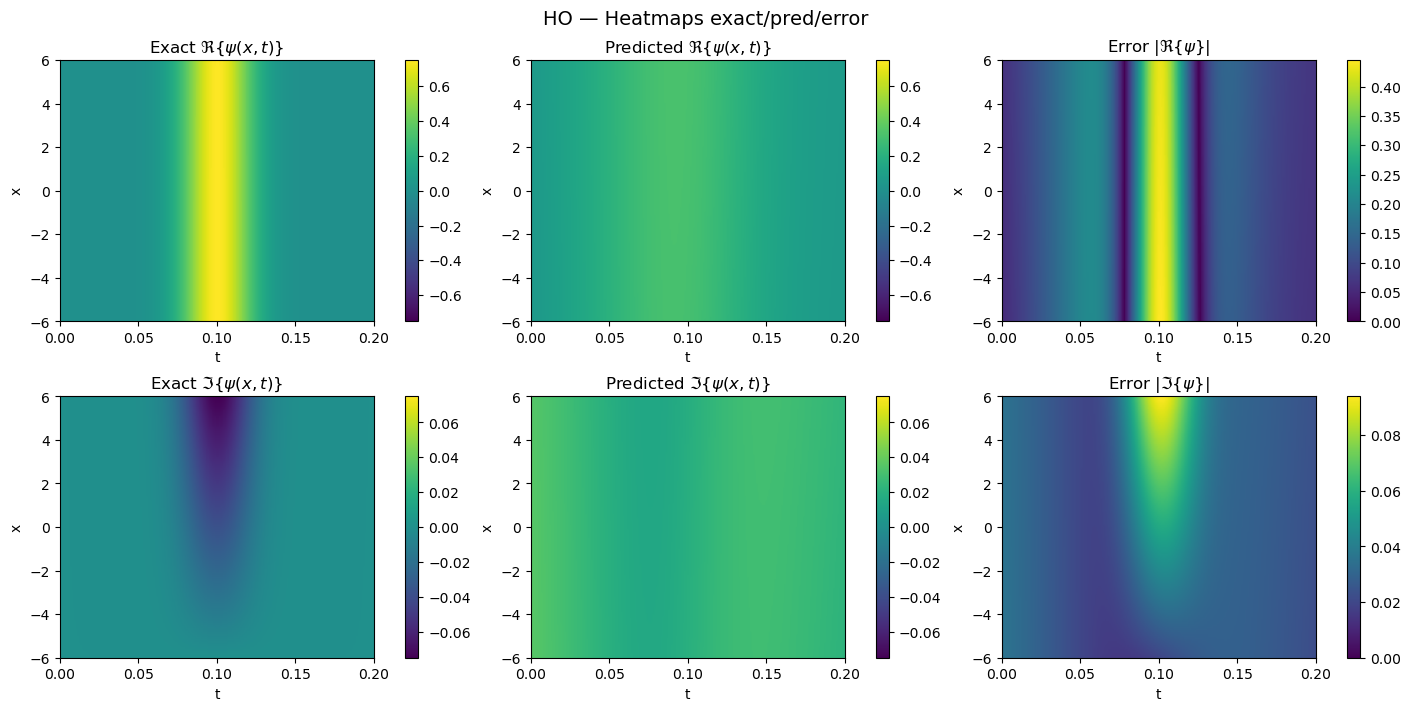

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Necesario: build_problem para exacta y dominio
from src.problems.schrodinger.problem import build_problem

@torch.no_grad()
def eval_model_in_chunks(model, tx, chunk=512):
    """
    Evalúa model(tx) en trozos para no reventar memoria y para no hacer una sola llamada gigante (útil en DV).
    tx: (N,2)
    """
    model.eval()
    outs = []
    N = tx.shape[0]
    for i in range(0, N, chunk):
        outs.append(model(tx[i:i+chunk]))
    return torch.cat(outs, dim=0)

def plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512):
    device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype

    problem = build_problem(eq_params, device=device, dtype=dtype)
    T = float(problem["T"])
    x_min = float(problem["x_min"])
    x_max = float(problem["x_max"])
    n_level = int(problem["n_level"])

    # mallas
    t = torch.linspace(0.0, T, Nt, device=device, dtype=dtype)
    x = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype)
    TT, XX = torch.meshgrid(t, x, indexing="ij")  # (Nt,Nx)

    t_flat = TT.reshape(-1, 1)
    x_flat = XX.reshape(-1, 1)
    tx = torch.cat([t_flat, x_flat], dim=1)

    # exacta
    psi_r_ex, psi_i_ex, _ = problem["exact"](n_level, t_flat, x_flat)

    # predicción
    psi_pred = eval_model_in_chunks(model, tx, chunk=chunk)
    psi_r_pr = psi_pred[:, 0:1]
    psi_i_pr = psi_pred[:, 1:2]

    # reshape a (Nt,Nx)
    Re_ex = psi_r_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Im_ex = psi_i_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Re_pr = psi_r_pr.reshape(Nt, Nx).detach().cpu().numpy()
    Im_pr = psi_i_pr.reshape(Nt, Nx).detach().cpu().numpy()

    Re_er = np.abs(Re_pr - Re_ex)
    Im_er = np.abs(Im_pr - Im_ex)

    # escalas razonables (simétricas para Re/Im; positivas para error)
    re_max = max(np.max(np.abs(Re_ex)), np.max(np.abs(Re_pr))) + 1e-12
    im_max = max(np.max(np.abs(Im_ex)), np.max(np.abs(Im_pr))) + 1e-12
    re_e_max = np.max(Re_er) + 1e-12
    im_e_max = np.max(Im_er) + 1e-12

    extent = [0.0, T, x_min, x_max]  # x-axis=t, y-axis=x

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

    # --- Re row ---
    im0 = axes[0,0].imshow(Re_ex, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,0].set_title(r"Exact $\Re\{\psi(x,t)\}$")
    plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

    im1 = axes[0,1].imshow(Re_pr, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,1].set_title(r"Predicted $\Re\{\psi(x,t)\}$")
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

    im2 = axes[0,2].imshow(Re_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=re_e_max)
    axes[0,2].set_title(r"Error $|\Re\{\psi\}|$")
    plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

    # --- Im row ---
    im3 = axes[1,0].imshow(Im_ex, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,0].set_title(r"Exact $\Im\{\psi(x,t)\}$")
    plt.colorbar(im3, ax=axes[1,0], fraction=0.046)

    im4 = axes[1,1].imshow(Im_pr, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,1].set_title(r"Predicted $\Im\{\psi(x,t)\}$")
    plt.colorbar(im4, ax=axes[1,1], fraction=0.046)

    im5 = axes[1,2].imshow(Im_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=im_e_max)
    axes[1,2].set_title(r"Error $|\Im\{\psi\}|$")
    plt.colorbar(im5, ax=axes[1,2], fraction=0.046)

    for ax in axes.flat:
        ax.set_xlabel("t")
        ax.set_ylabel("x")

    ex = str(eq_params.get("example", "schrodinger")).upper()
    fig.suptitle(f"{ex} — Heatmaps exact/pred/error", fontsize=14)
    plt.show()

# ---- úsalo así ----
plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512)



In [22]:
import torch
from src.problems.schrodinger.problem import build_problem

device = next(model.parameters()).device
dtype  = next(model.parameters()).dtype
problem = build_problem(eq_params, device=device, dtype=dtype)

T = problem["T"]
x = torch.linspace(problem["x_min"], problem["x_max"], 300, device=device, dtype=dtype).reshape(-1,1)
t = torch.full_like(x, float(T))

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], t, x)
    y = model(torch.cat([t, x], dim=1))
    re_pr, im_pr = y[:,0:1], y[:,1:2]

print("max|Re exact|:", re_ex.abs().max().item(), " max|Im exact|:", im_ex.abs().max().item())
print("max|Re pred |:", re_pr.abs().max().item(), " max|Im pred |:", im_pr.abs().max().item())
print("ratio exact Im/Re:", (im_ex.abs().max()/re_ex.abs().max()).item())
print("ratio pred  Im/Re:", (im_pr.abs().max()/re_pr.abs().max()).item())


max|Re exact|: 0.7472226023674011  max|Im exact|: 0.07497233897447586
max|Re pred |: 0.32169410586357117  max|Im pred |: 0.0352587066590786
ratio exact Im/Re: 0.10033467411994934
ratio pred  Im/Re: 0.10960321128368378


In [23]:
run_logger.flush_figures()
print("Figuras guardadas:", len(list(run_logger.fig_dir.glob("*.png"))))


Figuras guardadas: 7
